In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.tsa.api as tsa
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score,mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LassoCV
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Preprocess

In [ ]:
df = pd.read_csv('CO2 Emissions_Canada.csv')
df = df.dropna()
df.sort_values(by=['Make', 'Model', 'Vehicle Class'], inplace=True)
df = df.reindex(list(range(len(df))), axis=0)
mask = df.duplicated(keep=False)
duplicated_rows = df[mask]
df.drop_duplicates(keep='first', inplace=True, ignore_index=True)
df_encoded = pd.get_dummies(df, drop_first=True)
y = df_encoded['CO2 Emissions(g/km)']
X = df_encoded.drop(columns=['CO2 Emissions(g/km)'])
X = sm.add_constant(X)
X = X.astype(float)
model = sm.OLS(y, X).fit()
print("Full OLS Model Summary:")
print(model.summary())
X_lasso = X.drop(columns='const')

lasso = LassoCV(cv=5, random_state=42).fit(X_lasso, y)
selected_features = X_lasso.columns[lasso.coef_ != 0]
print("\nSelected features via Lasso:", selected_features.tolist())
X_selected = X[selected_features]
X_selected = sm.add_constant(X_selected)
cols_to_drop = [
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (mpg)'
]
X_selected = X_selected.drop(columns=cols_to_drop)
X_reduced = X_selected.copy()
model_selected = sm.OLS(y, X_selected).fit()
print("\nOLS Model After Lasso Feature Selection:")
print(model_selected.summary())

from statsmodels.regression.linear_model import GLSAR
model = GLSAR(y, X_selected, rho=1).fit()

Full OLS Model Summary:
                             OLS Regression Results                            
Dep. Variable:     CO2 Emissions(g/km)   R-squared:                       0.997
Model:                             OLS   Adj. R-squared:                  0.996
Method:                  Least Squares   F-statistic:                     686.2
Date:                 Tue, 13 May 2025   Prob (F-statistic):               0.00
Time:                         03:33:20   Log-Likelihood:                -16208.
No. Observations:                 6282   AIC:                         3.661e+04
Df Residuals:                     4185   BIC:                         5.075e+04
Df Model:                         2096                                         
Covariance Type:             nonrobust                                         
                                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

In [ ]:
# def backward_elimination(X, y, p_thresh=0.05):
#     X = X.copy()
#     while True:
#         model = sm.OLS(y, X).fit()
#         pvals = model.pvalues.drop('const', errors='ignore')
#         worst_pval = pvals.max()
#         if worst_pval > p_thresh:
#             worst_feature = pvals.idxmax()
#             X = X.drop(columns=[worst_feature])
#         else:
#             break
#     return sm.OLS(y, X).fit()

# model_final = backward_elimination(X, y)
# print(model_final.summary())

# Assumptions

1. Linear in Parameters

In [ ]:
def check_linearity(X, model):
  """
  Plot model residuals vs X_i to check for linearity
  If LOWESS line is at 0, then the model is linear
  """
  residuals = model.resid
  for col in X.columns:
    if col == 'const':
      continue
    plt.figure(figsize=(6, 4))

    unique_vals = sorted(X[col].dropna().unique())
    if set(unique_vals).issubset({0, 1}):
      sns.boxplot(x=X[col], y=residuals,
                  boxprops=dict(facecolor='none', edgecolor='black'),
                  showcaps=True, whiskerprops={'color':'black'},
                  medianprops={'color': 'red'})
      sns.stripplot(x=X[col], y=residuals,
                    jitter=True, color='blue', alpha=0.4, size=3)
      plt.axhline(y=0, linestyle='--', color='gray', alpha=0.5)
      plt.title(f"Residuals by {col} (Binary)")
    else:
      sns.regplot(x=X[col], y=residuals, lowess=True,
                  line_kws={'color': 'black'},
                  scatter_kws={'s': 10, 'alpha': 0.5})
    plt.xlabel(col)
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs. {col}")
    plt.tight_layout()
    plt.show()

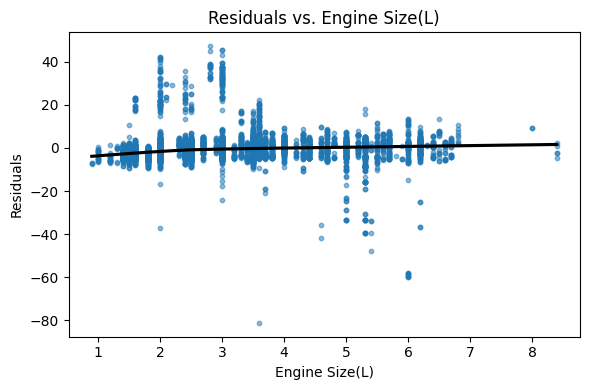

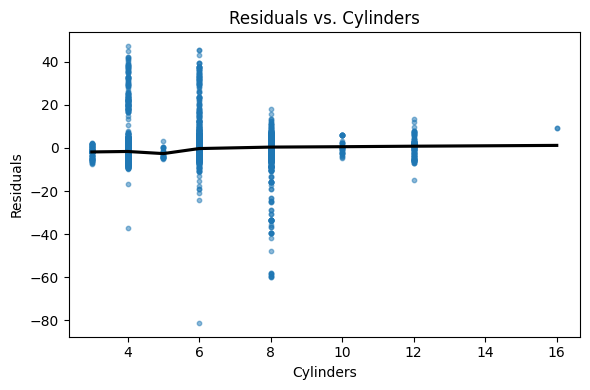

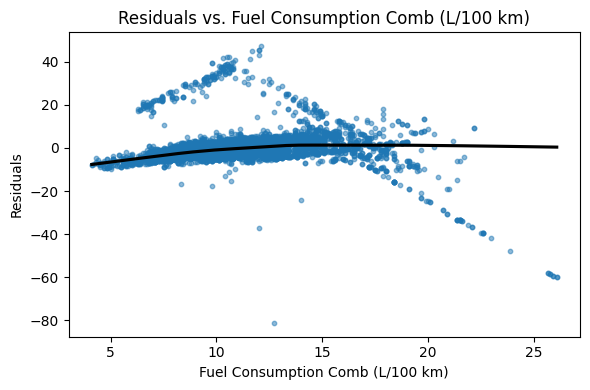

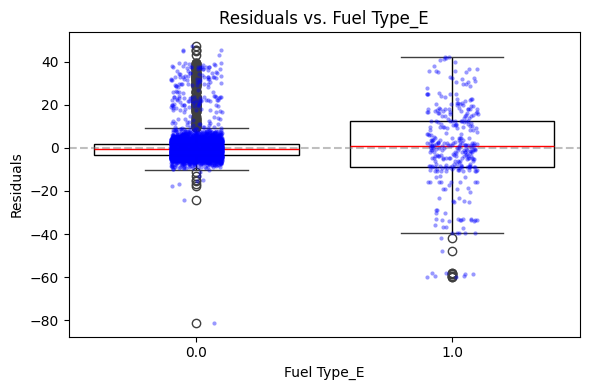

In [ ]:
# RUN FUNCTION
check_linearity(X_selected, model_selected)

2. Constant variance

In [ ]:
def check_constant_variance(X, model):
  """
  Plot absolute value of model residuals vs X_i to check for constant variance
  If LOWESS line is constant, then the model has constant variance
  """
  abs_resid = np.abs(model.resid)
  for col in X.columns:
    if col == 'const':
      continue

    plt.figure(figsize=(6, 4))
    unique_vals = sorted(X[col].dropna().unique())
    if set(unique_vals).issubset({0, 1}):
      sns.boxplot(x=X[col], y=abs_resid,
                  boxprops=dict(facecolor='none', edgecolor='black'),
                  showcaps=True, whiskerprops={'color':'black'},
                  medianprops={'color': 'red'})
      sns.stripplot(x=X[col], y=abs_resid,
                    jitter=True, color='blue', alpha=0.4, size=3)
    else:
      sns.regplot(x=X[col], y=abs_resid, lowess=True,
                  line_kws={'color': 'black'},
                  scatter_kws={'s': 10, 'alpha': 0.5})
    plt.xlabel(col)
    plt.ylabel("Absolute Residuals")
    plt.title(f"Absolute Residuals vs. {col}")
    plt.tight_layout()
    plt.show()

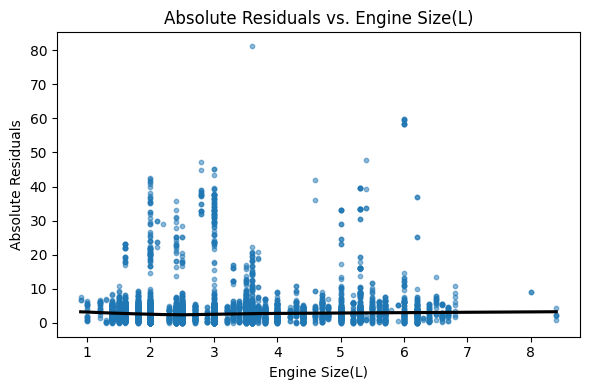

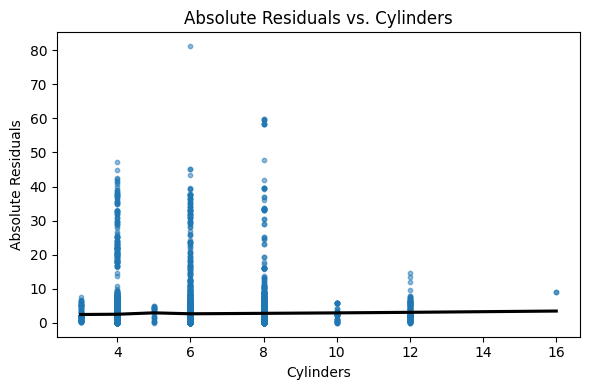

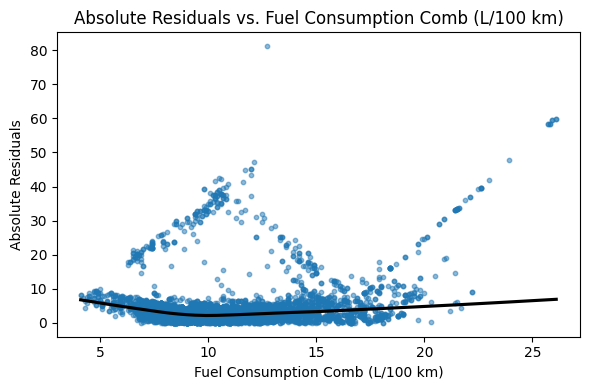

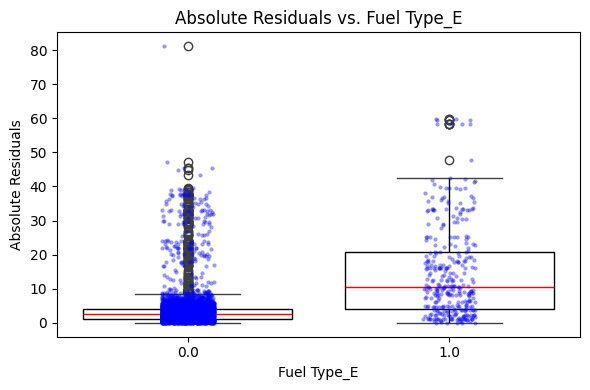

In [ ]:
# RUN FUNCTION
check_constant_variance(X_selected, model_selected)

3. Independence

In [ ]:
def check_independence(model):
  """
  Plot autocorrelation plot to check for independence
  """
  plot_acf(model.resid)
  plt.xlabel('Lag')
  plt.ylabel('Autocorrelation')
  plt.title('Autocorrelation Plot')
  plt.tight_layout()
  plt.show()

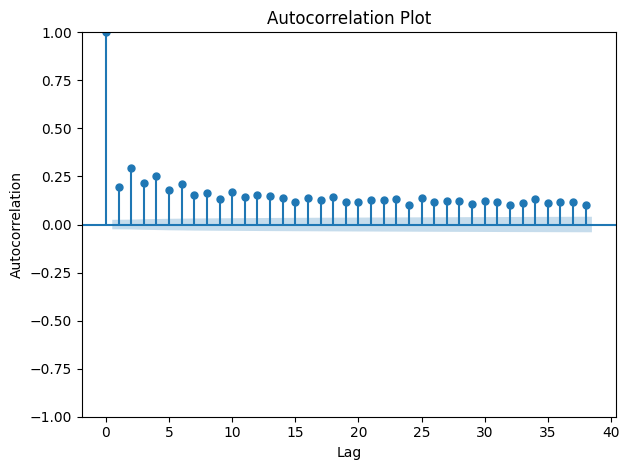

In [ ]:
# RUN FUNCTION
check_independence(model)

4. Normality

In [ ]:
def check_normality(model):
  """
  Plot Q-Q plot to check for normality
  If the points on the Q-Q plot fall along a straight & diagonal line, then the residuals are normally distributed
  """
  sm.qqplot(model.resid, line='r')
  plt.xlabel('Theoretical Quantiles')
  plt.ylabel('Sample Quantiles')
  plt.title('Q-Q Plot')
  plt.tight_layout()
  plt.show()


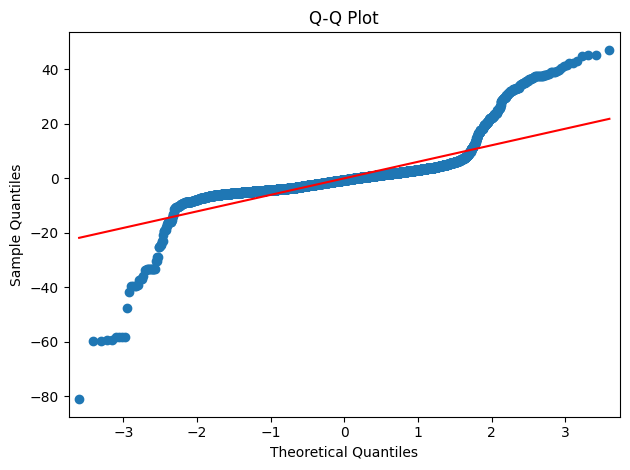

In [ ]:
# RUN FUNCTION
check_normality(model_selected)

# Train and Test


Mean Squared Error: 65.48
Average Squared Error: 4.34
Correlation between actual and predicted: 0.9910


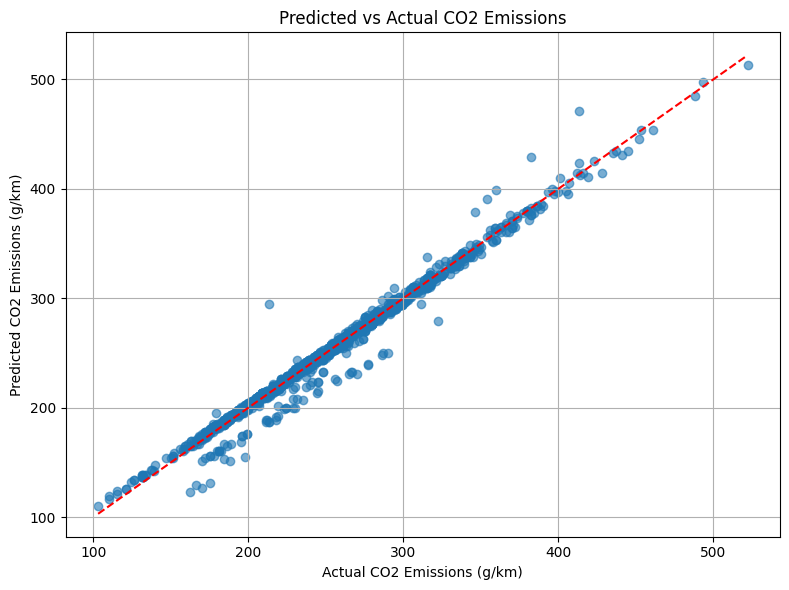

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

# Fit OLS model on training data
model_selected = sm.OLS(y_train, X_train).fit()

# Predict on test set
y_pred = model_selected.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
mae_test = mean_absolute_error(y_test, y_pred)
print(f"\nMean Squared Error: {mse:.2f}")
print(f"Average Squared Error: {mae_test:.2f}")  # same as MSE
correlation = np.corrcoef(y_test, y_pred)[0, 1]
print(f"Correlation between actual and predicted: {correlation:.4f}")
# ====== Plot Predictions vs Actual ======
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.xlabel('Actual CO2 Emissions (g/km)')
plt.ylabel('Predicted CO2 Emissions (g/km)')
plt.title('Predicted vs Actual CO2 Emissions')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X_reduced.columns
vif_data["VIF"] = [variance_inflation_factor(X_reduced.values, i)
                   for i in range(X_reduced.shape[1])]

print(vif_data)


vif_data = pd.DataFrame()
vif_data["Feature"] = X_selected.columns
vif_data["VIF"] = [variance_inflation_factor(X_selected.values, i)
                   for i in range(X_selected.shape[1])]

print(vif_data)


                            Feature        VIF
0                             const  25.994060
1                    Engine Size(L)   8.898367
2                         Cylinders   7.630490
3  Fuel Consumption Comb (L/100 km)   4.868929
4                       Fuel Type_E   1.644121
                            Feature        VIF
0                             const  25.994060
1                    Engine Size(L)   8.898367
2                         Cylinders   7.630490
3  Fuel Consumption Comb (L/100 km)   4.868929
4                       Fuel Type_E   1.644121


In [ ]:
X = data.drop(['charges','region'], axis = 1)
Y = data.charges



quad = PolynomialFeatures (degree = 2)
x_quad = quad.fit_transform(X)

X_train,X_test,Y_train,Y_test = train_test_split(x_quad,Y, random_state = 0)

plr = LinearRegression().fit(X_train,Y_train)

Y_train_pred = plr.predict(X_train)
Y_test_pred = plr.predict(X_test)

print(plr.score(X_test,Y_test))
mse_test = mean_squared_error(Y_test, Y_test_pred)
mae_test = mean_absolute_error(Y_test, Y_test_pred)

print("R² on test set: %.3f" % plr.score(X_test, Y_test))
print("MSE on test set: %.2f" % mse_test)
print("Average wrongness (MAE) on test set: %.2f" % mae_test)


NameError: name 'data' is not defined